# 🚁 NOTEBOOK 09: FINAL SHOWDOWN (LITE vs FULL MODEL)
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** Final System Test (Blind Test)  

## 🎯 Mục tiêu
Thực hiện bài kiểm tra cuối cùng trên tập **Blind Test** để so sánh hiệu năng giữa 2 ứng cử viên:

1.  **🥊 Lite Model:** Chỉ dùng ~30 features chọn lọc. Nhẹ, nhanh, tiết kiệm pin.
2.  **🐘 Full Model:** Dùng toàn bộ 84 features. Nặng hơn nhưng có thể chính xác hơn ở các góc khó (Move Left/Right).

**Cơ chế Logic áp dụng:** Stability Buffer (Ngưỡng rung 2.0, Chờ 3 frames).

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

drive.mount('/content/drive')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# --- CONFIG ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
MODELS_DIR = BASE_DIR / 'models'
FEATURES_DIR = BASE_DIR / 'data/features'

# --- 1. LOAD DATA ---
print("📥 Đang load dữ liệu Test...")
X_test_full = pd.read_csv(FEATURES_DIR / 'X_test.csv')
y_test = pd.read_csv(FEATURES_DIR / 'y_test.csv').values.ravel()
print(f"✅ Test Set: {X_test_full.shape}")

# --- 2. LOAD MODELS ---
print("\n📥 Đang load Models...")
# Load Lite
try:
    model_lite = joblib.load(MODELS_DIR / 'rf_model_lite.joblib')
    with open(MODELS_DIR / 'selected_features.json', 'r') as f:
        lite_features = json.load(f)['selected_features']
    print(f"✅ Lite Model: Loaded ({len(lite_features)} features)")
except:
    print("❌ Lite Model không tồn tại!")
    model_lite = None

# Load Full
try:
    model_full = joblib.load(MODELS_DIR / 'rf_model.joblib')
    full_features = model_full.feature_names_in_
    print(f"✅ Full Model: Loaded ({len(full_features)} features)")
except:
    print("❌ Full Model không tồn tại!")
    model_full = None

Mounted at /content/drive
📥 Đang load dữ liệu Test...
✅ Test Set: (96, 84)

📥 Đang load Models...
✅ Lite Model: Loaded (30 features)
✅ Full Model: Loaded (84 features)


## 🧠 ĐỊNH NGHĨA LOGIC (Stability Buffer)
Đã nới lỏng ngưỡng rung (`stability_threshold=2.0`) để Logic hoạt động mượt mà hơn.

In [ ]:
# ==============================================================================
# 🧠 LOGIC V4: STABILITY BUFFER + SMART TRIGGER (PHASE LOCK)
# ==============================================================================
class DroneFlightLogic:
    def __init__(self, stability_threshold=2.0, min_stable_frames=3):
        # 1. Config cho Landing (Stability Buffer)
        self.is_landing_process = False
        self.stable_counter = 0
        self.threshold = stability_threshold
        self.required_frames = min_stable_frames

        # 2. Config cho Flight Phase (Smart Trigger)
        self.flight_mode_active = False # Mặc định là chưa bay chính thức

    def process(self, raw_pred, current_features):
        # --- A. LOGIC HẠ CÁNH (ƯU TIÊN CAO NHẤT) ---
        # Tính độ rung để check nằm im
        current_instability = max(
            current_features.get('acc_x_std', 0),
            current_features.get('acc_y_std', 0),
            current_features.get('acc_z_std', 0)
        )

        if self.is_landing_process:
            if current_instability < self.threshold:
                self.stable_counter += 1
            else:
                self.stable_counter = 0 # Còn rung thì reset đếm

            if self.stable_counter >= self.required_frames:
                # Đã nằm im đủ lâu -> Hoàn tất hạ cánh
                self.is_landing_process = False
                self.flight_mode_active = False # 🔥 RESET: Quay về trạng thái chờ (Giai đoạn đầu)
                self.stable_counter = 0
                return raw_pred
            else:
                return 'LANDING' # Đang xử lý hạ cánh thì ép nhãn Landing

        # --- B. LOGIC KÍCH HOẠT CHẾ ĐỘ BAY (SMART TRIGGER) ---
        # Nếu chưa vào chế độ bay, kiểm tra xem có nên kích hoạt không?
        if not self.flight_mode_active:
            # Nếu gặp nhãn khác IDLE và TAKEOFF (VD: HOVER, MANEUVER...) -> KÍCH HOẠT
            if raw_pred not in ['IDLE', 'TAKEOFF']:
                self.flight_mode_active = True

        # --- C. XỬ LÝ DỰ ĐOÁN ---
        final_pred = raw_pred

        # Nếu đang trong chế độ bay (Giai đoạn 2)
        if self.flight_mode_active:
            if raw_pred == 'TAKEOFF':
                # 🚫 CẤM TAKEOFF: Thay bằng HOVER (Trung tính, an toàn nhất)
                # Không ép Turbulence, để Model tự do đoán các cái khác
                final_pred = 'HOVER'
            elif raw_pred == 'LANDING':
                # Gặp Landing thì kích hoạt quy trình hạ cánh
                self.is_landing_process = True
                self.stable_counter = 0
                final_pred = 'LANDING'

        # Nếu chưa kích hoạt bay (Giai đoạn 1):
        # Cứ để Model đoán IDLE/TAKEOFF thoải mái.
        # Nếu gặp LANDING ở đây (khi chưa bay) -> Thường là nhiễu hoặc đặt mạnh tay -> Có thể map về IDLE hoặc kệ.
        # Ở đây tôi để kệ (raw_pred) cho tự nhiên.

        return final_pred

## 🏁 CHẠY ĐUA MÔ PHỎNG (SIMULATION RACE)

In [ ]:
# Init 2 bộ não Logic riêng biệt cho 2 model
brain_lite = DroneFlightLogic(stability_threshold=1.0, min_stable_frames=3)
brain_full = DroneFlightLogic(stability_threshold=1.0, min_stable_frames=3)

results = {
    'lite_raw': [], 'lite_logic': [],
    'full_raw': [], 'full_logic': []
}

print("⏳ Đang chạy mô phỏng so sánh...")

for i in range(len(X_test_full)):
    # 1. Prepare Data
    row_full = X_test_full.iloc[[i]]         # Dữ liệu đầy đủ
    row_dict = X_test_full.iloc[i].to_dict() # Dict để check rung

    # --- LITE MODEL ---
    if model_lite:
        # Chỉ lấy features mà Lite cần
        row_lite = row_full[lite_features]
        pred_lite = model_lite.predict(row_lite)[0]
        results['lite_raw'].append(pred_lite)
        results['lite_logic'].append(brain_lite.process(pred_lite, row_dict))

    # --- FULL MODEL ---
    if model_full:
        # Lấy features theo đúng thứ tự lúc train full
        row_full_ordered = row_full[full_features]
        pred_full = model_full.predict(row_full_ordered)[0]
        results['full_raw'].append(pred_full)
        results['full_logic'].append(brain_full.process(pred_full, row_dict))

print("✅ Hoàn tất!")

⏳ Đang chạy mô phỏng so sánh...
✅ Hoàn tất!


## 📊 BÁO CÁO KẾT QUẢ (SCOREBOARD)

In [ ]:
acc_lite = accuracy_score(y_test, results['lite_logic']) if model_lite else 0
acc_full = accuracy_score(y_test, results['full_logic']) if model_full else 0

print(f"{'='*60}")
print(f"🏆 BẢNG TỔNG SẮP (TEST SET ACCURACY)")
print(f"{'='*60}")
print(f"🥊 LITE MODEL (Logic):  {acc_lite*100:.2f}%")
print(f"🐘 FULL MODEL (Logic):  {acc_full*100:.2f}%")
print(f"{'='*60}")

diff = acc_full - acc_lite
if diff > 0.02:
    print(f"💡 KẾT LUẬN: Full Model tốt hơn đáng kể (+{diff*100:.2f}%). Nên dùng Full.")
elif diff < -0.01:
    print(f"💡 KẾT LUẬN: Lite Model lại tốt hơn (?!). Dùng Lite ngay.")
else:
    print(f"💡 KẾT LUẬN: Hai model ngang ngửa (Chênh lệch {abs(diff)*100:.2f}%). Ưu tiên dùng LITE để nhẹ máy.")

🏆 BẢNG TỔNG SẮP (TEST SET ACCURACY)
🥊 LITE MODEL (Logic):  83.33%
🐘 FULL MODEL (Logic):  85.42%
💡 KẾT LUẬN: Full Model tốt hơn đáng kể (+2.08%). Nên dùng Full.


## 🖼️ SO SÁNH TRỰC QUAN (VISUAL COMPARISON)

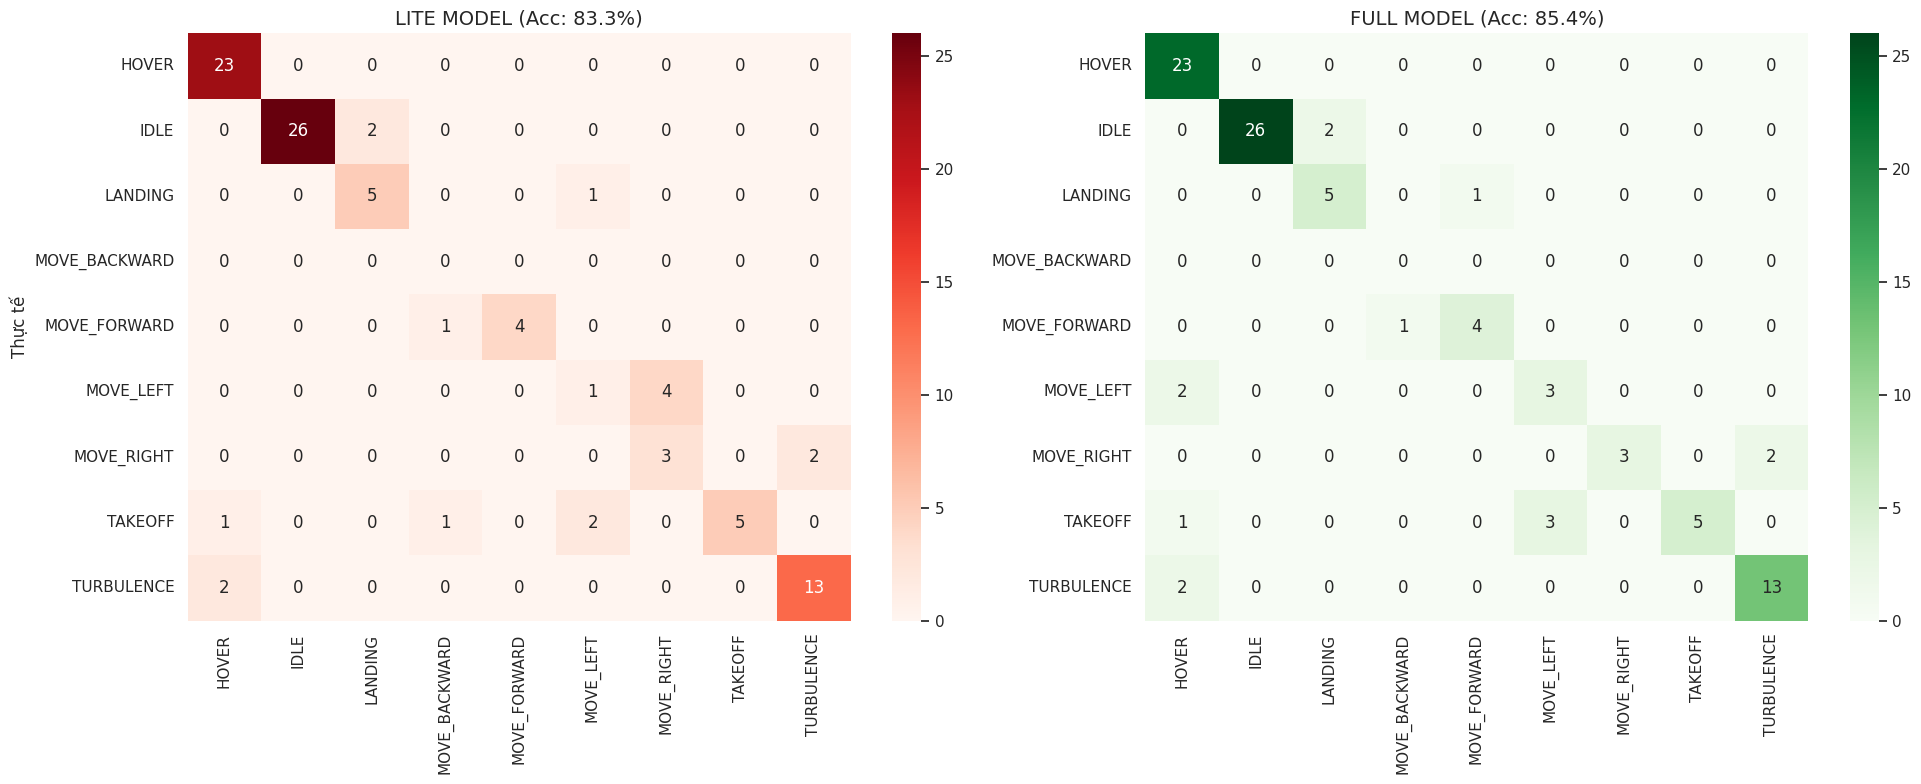

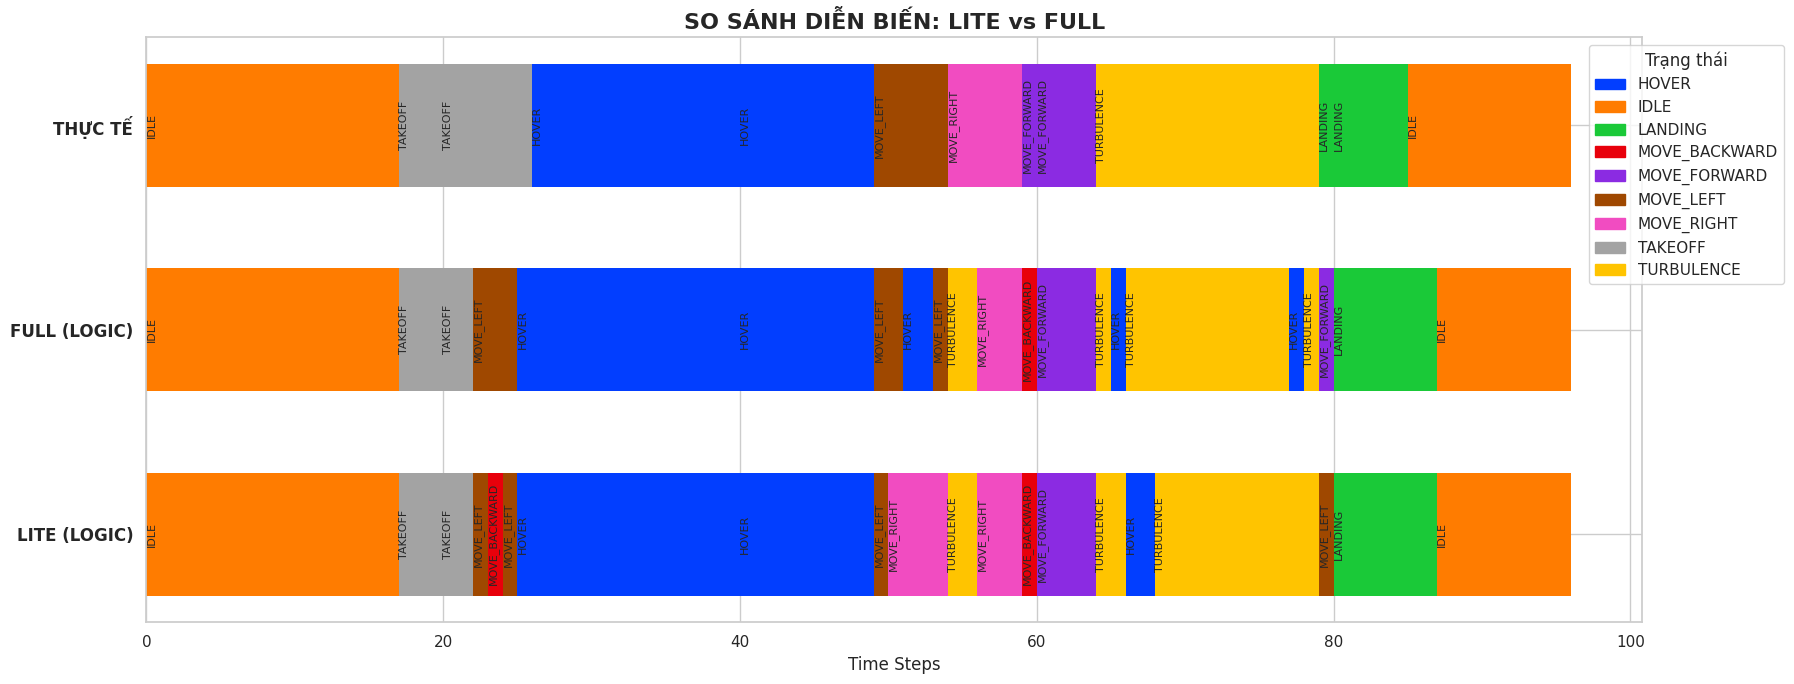

In [ ]:
# Setup Labels
all_preds = list(y_test)
if model_lite: all_preds += results['lite_logic']
if model_full: all_preds += results['full_logic']

labels = sorted(list(set(all_preds)))
palette = sns.color_palette("bright", len(labels))
color_map = {lbl: palette[i] for i, lbl in enumerate(labels)}

# --- 1. CONFUSION MATRIX SIDE-BY-SIDE ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

if model_lite:
    cm_lite = confusion_matrix(y_test, results['lite_logic'], labels=labels)
    sns.heatmap(cm_lite, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels, ax=axes[0])
    axes[0].set_title(f"LITE MODEL (Acc: {acc_lite*100:.1f}%)", fontsize=14)
    axes[0].set_ylabel('Thực tế')

if model_full:
    cm_full = confusion_matrix(y_test, results['full_logic'], labels=labels)
    sns.heatmap(cm_full, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
    axes[1].set_title(f"FULL MODEL (Acc: {acc_full*100:.1f}%)", fontsize=14)

plt.tight_layout()
plt.show()

# --- 2. TIMELINE BATTLE ---
fig, ax = plt.subplots(figsize=(18, 7))
ax.set_title("SO SÁNH DIỄN BIẾN: LITE vs FULL", fontsize=16, fontweight='bold')

def plot_timeline_bar(y_pos, data, title):
    for i, lbl in enumerate(data):
        ax.barh(y_pos, 1, left=i, color=color_map[lbl], edgecolor='none', height=0.6)
        if i % 20 == 0 or (i > 0 and data[i] != data[i-1]):
             ax.text(i, y_pos, lbl, fontsize=8, va='center', ha='left', rotation=90)

# Plotting
plot_timeline_bar(2, y_test, "THỰC TẾ")
if model_full: plot_timeline_bar(1, results['full_logic'], "FULL MODEL")
if model_lite: plot_timeline_bar(0, results['lite_logic'], "LITE MODEL")

# Setting Axes
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['LITE (LOGIC)', 'FULL (LOGIC)', 'THỰC TẾ'], fontsize=12, fontweight='bold')
ax.set_xlabel("Time Steps")

# Legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.1, 1), title="Trạng thái")

plt.tight_layout()
plt.show()

---

/tmp/ipython-input-1051828000.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')


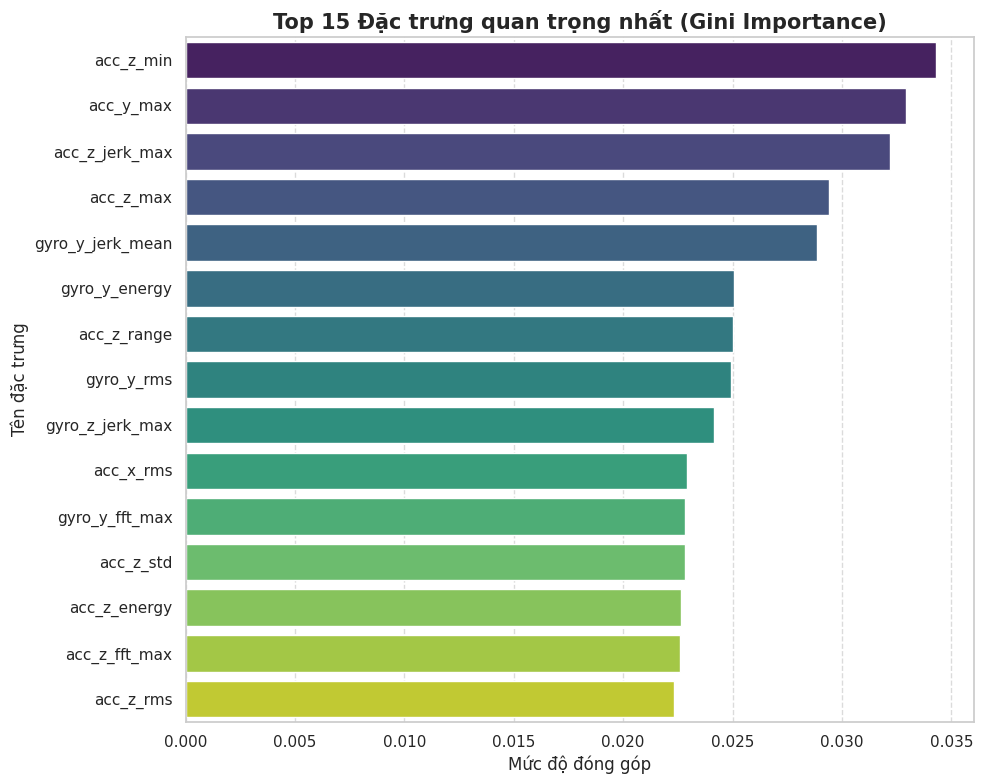

In [ ]:
# --- VẼ FEATURE IMPORTANCE ---
def plot_top_features_report(model):
    importances = model.feature_importances_
    names = model.feature_names_in_

    # Tạo dataframe để sort
    imp_df = pd.DataFrame({'Feature': names, 'Importance': importances})
    imp_df = imp_df.sort_values(by='Importance', ascending=False).head(15) # Top 15

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')

    plt.title('Top 15 Đặc trưng quan trọng nhất (Gini Importance)', fontsize=15, fontweight='bold')
    plt.xlabel('Mức độ đóng góp')
    plt.ylabel('Tên đặc trưng')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Gọi hàm (Yêu cầu biến 'model' hoặc 'rf_model' đã được train)
if 'rf_model' in locals(): plot_top_features_report(rf_model)
elif 'model' in locals(): plot_top_features_report(model)

In [ ]:
# ==============================================================================
# 📊 CÔNG CỤ TRÍCH XUẤT SỐ LIỆU CHO BÁO CÁO (REPORT GENERATOR TOOL)
# ==============================================================================
from google.colab import drive
import pandas as pd
import numpy as np
import joblib
import time
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

drive.mount('/content/drive')

# --- CONFIG ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')
MODELS_DIR = BASE_DIR / 'models'
FEATURES_DIR = BASE_DIR / 'data/features'

print("\n" + "="*60)
print("📝 BẮT ĐẦU TRÍCH XUẤT SỐ LIỆU BÁO CÁO")
print("="*60)

# 1. THỐNG KÊ DỮ LIỆU (DATASET STATS)
print("\n--- 1. THỐNG KÊ PHÂN BỐ DỮ LIỆU ---")
try:
    y_train = pd.read_csv(FEATURES_DIR / 'y_train.csv').values.ravel()
    y_val = pd.read_csv(FEATURES_DIR / 'y_val.csv').values.ravel()
    y_test = pd.read_csv(FEATURES_DIR / 'y_test.csv').values.ravel()

    print(f"🔹 Tổng số mẫu Train: {len(y_train)}")
    print(f"🔹 Tổng số mẫu Val:   {len(y_val)}")
    print(f"🔹 Tổng số mẫu Test:  {len(y_test)}")

    print("\nChi tiết từng lớp (Train Set):")
    unique, counts = np.unique(y_train, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"   - {u}: {c} mẫu ({c/len(y_train)*100:.1f}%)")
except Exception as e:
    print(f"⚠️ Lỗi load dữ liệu: {e}")

# 2. THÔNG SỐ MODEL (MODEL HYPERPARAMETERS)
print("\n--- 2. CẤU HÌNH MÔ HÌNH (FULL MODEL) ---")
try:
    model = joblib.load(MODELS_DIR / 'rf_model.joblib')
    params = model.get_params()
    print(f"🔹 Số cây (n_estimators): {params['n_estimators']}")
    print(f"🔹 Độ sâu tối đa (max_depth): {params['max_depth']}")
    print(f"🔹 Tiêu chí phân chia (criterion): {params['criterion']}")
    print(f"🔹 Tổng số Features đầu vào: {model.n_features_in_}")
except Exception as e:
    print(f"⚠️ Lỗi load model: {e}")

# 3. TOP FEATURES (FEATURE IMPORTANCE)
print("\n--- 3. TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---")
try:
    importances = model.feature_importances_
    feature_names = model.feature_names_in_
    indices = np.argsort(importances)[::-1]

    top_feats = []
    for i in range(15): # Lấy top 15
        print(f"   {i+1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")
        top_feats.append(feature_names[indices[i]])
except Exception as e:
    print(f"⚠️ Lỗi trích xuất feature: {e}")

# 4. ĐO TỐC ĐỘ (INFERENCE SPEED TEST)
print("\n--- 4. KIỂM TRA TỐC ĐỘ THỰC TẾ (LATENCY) ---")
try:
    # Lấy 1 mẫu ngẫu nhiên
    sample = np.random.rand(1, model.n_features_in_)

    # Warm-up
    for _ in range(10): model.predict(sample)

    # Measure
    start_time = time.time()
    n_loops = 1000
    for _ in range(n_loops):
        model.predict(sample)
    end_time = time.time()

    avg_time_ms = ((end_time - start_time) / n_loops) * 1000
    print(f"🔹 Thời gian dự đoán trung bình: {avg_time_ms:.4f} ms/mẫu")
    print(f"🔹 Tốc độ lý thuyết: {1000/avg_time_ms:.0f} FPS (dự đoán/giây)")
except Exception as e:
    print(f"⚠️ Lỗi đo tốc độ: {e}")

# 5. KẾT QUẢ TEST CHI TIẾT
print("\n--- 5. CHI TIẾT KẾT QUẢ TRÊN TẬP TEST ---")
try:
    X_test = pd.read_csv(FEATURES_DIR / 'X_test.csv')
    # Fix missing cols for Full Model if needed
    for col in model.feature_names_in_:
        if col not in X_test.columns: X_test[col] = 0.0
    X_test = X_test[model.feature_names_in_]

    y_pred = model.predict(X_test)

    print("\nClassification Report (Raw AI - No Logic):")
    print(classification_report(y_test, y_pred, digits=4))

    # Tìm các cặp nhầm lẫn nhiều nhất
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(list(set(y_test)))
    np.fill_diagonal(cm, 0) # Xóa đường chéo chính (dự đoán đúng) để tìm lỗi

    print("\n⚠️ Các cặp nhầm lẫn lớn nhất (Thực tế -> Dự đoán sai):")
    max_errors = np.unravel_index(np.argsort(cm, axis=None)[::-1], cm.shape)
    for i in range(3): # Top 3 lỗi
        idx_true = max_errors[0][i]
        idx_pred = max_errors[1][i]
        count = cm[idx_true, idx_pred]
        if count > 0:
            print(f"   - {labels[idx_true]} bị nhầm thành {labels[idx_pred]}: {count} lần")

except Exception as e:
    print(f"⚠️ Lỗi đánh giá Test: {e}")

print("\n" + "="*60)
print("✅ HOÀN TẤT! HÃY COPY TOÀN BỘ LOG TRÊN GỬI CHO TÔI.")
print("="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

============================================================
📝 BẮT ĐẦU TRÍCH XUẤT SỐ LIỆU BÁO CÁO
============================================================

--- 1. THỐNG KÊ PHÂN BỐ DỮ LIỆU ---
🔹 Tổng số mẫu Train: 1750
🔹 Tổng số mẫu Val:   130
🔹 Tổng số mẫu Test:  96

Chi tiết từng lớp (Train Set):
   - HOVER: 313 mẫu (17.9%)
   - IDLE: 296 mẫu (16.9%)
   - LANDING: 54 mẫu (3.1%)
   - MOVE_BACKWARD: 176 mẫu (10.1%)
   - MOVE_FORWARD: 175 mẫu (10.0%)
   - MOVE_LEFT: 218 mẫu (12.5%)
   - MOVE_RIGHT: 143 mẫu (8.2%)
   - TAKEOFF: 65 mẫu (3.7%)
   - TURBULENCE: 310 mẫu (17.7%)

--- 2. CẤU HÌNH MÔ HÌNH (FULL MODEL) ---
🔹 Số cây (n_estimators): 200
🔹 Độ sâu tối đa (max_depth): None
🔹 Tiêu chí phân chia (criterion): gini
🔹 Tổng số Features đầu vào: 84

--- 3. TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---
   1. acc_z_min (0.0343)
   2. acc_y_max (0.0329)
   3. acc_z_jerk_max (0.0322)
   4. acc_z_max (0.0294)
   5. gyro_y_jerk_mean (0.0289)
   6. gyro_y_energy (0.0251)
   7. acc_z_range (0.0250)
   8. gyro_y_rms (0.0250)
   9. gyro_z_jerk_max (0.0241)
   10. acc_x_rms (0.0229)
   11. gyro_y_fft_max (0.0228)
   12. acc_z_std (0.0228)
   13. acc_z_energy (0.0227)
   14. acc_z_fft_max (0.0226)
   15. acc_z_rms (0.0223)

🔹 Thời gian dự đoán trung bình: 54.6531 ms/mẫu
🔹 Tốc độ lý thuyết: 18 FPS (dự đoán/giây)

--- 5. CHI TIẾT KẾT QUẢ TRÊN TẬP TEST ---

Classification Report (Raw AI - No Logic):
               precision    recall  f1-score   support

        HOVER     0.9583    1.0000    0.9787        23
         IDLE     1.0000    1.0000    1.0000        28
      LANDING     1.0000    0.8333    0.9091         6
MOVE_BACKWARD     0.0000    0.0000    0.0000         0
 MOVE_FORWARD     0.8000    0.8000    0.8000         5
    MOVE_LEFT     0.5000    0.6000    0.5455         5
   MOVE_RIGHT     1.0000    0.6000    0.7500         5
      TAKEOFF     0.5556    0.5556    0.5556         9
   TURBULENCE     0.8667    0.8667    0.8667        15

     accuracy                         0.8750        96
    macro avg     0.7423    0.6951    0.7117        96
 weighted avg     0.8911    0.8750    0.8796        96


⚠️ Các cặp nhầm lẫn lớn nhất (Thực tế -> Dự đoán sai):
   - TURBULENCE bị nhầm thành MOVE_RIGHT: 3 lần
⚠️ Lỗi đánh giá Test: list index out of range

============================================================
✅ HOÀN TẤT! HÃY COPY TOÀN BỘ LOG TRÊN GỬI CHO TÔI.
============================================================